# Hierarchical Cascade Model Results Visualization

This notebook loads and visualizes results from the three-level hierarchical cascade model:
- **Level 1**: Sepsis prediction (binary)
- **Level 2**: Hemocultive result (multiclass)
- **Level 3**: Cephalosporin resistance (binary)


In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

LOCAL_OUTPUT_DIR = "/home/pmata/mepram_data"

## 0. Best Model Selection Across Runs

Scans `root_folder` for all `cascade_three_level_*` output directories, filters by an optional `limit_date`, loads every `aggregate_summary.json`, and ranks runs by a weighted composite score across all six metrics (L1/L2/L3 AUC and F1).

**Config knobs** (edit the cell below):
- `root_folder` – parent directory containing all training run outputs
- `limit_date` – `"YYYYMMDD"` upper bound on the run timestamp, or `None` for all runs
- `SCORE_WEIGHTS` – per-metric weights for the composite score (L3 metrics are double-weighted by default)

At the end of the cell, `results_dir` is automatically updated to point at the best run, so the rest of the notebook will analyse it immediately.

Found 4 valid runs up to 20260301

RUNS RANKED BY COMPOSITE SCORE
                                                                     run         run_datetime max_features  Sepsis_auc  Sepsis_f1  l1_n_features  Etiologia_auc  Etiologia_f1  l2_n_features  Cef_Resist_auc  Cef_Resist_f1  l3_n_features  composite_score
0  hierarchical_independent_featureesp_lgbm_1000f_20260320121018_5457755  2026-03-20 12:10:18         1000      0.9291     0.8672             47         0.7304        0.4590             47          0.7363         0.5840             47           0.7033
1    hierarchical_independent_featureesp_lgbm_50f_20260320120944_5457491  2026-03-20 12:09:44           50      0.9294     0.8643             47         0.7283        0.4447             47          0.7263         0.5970             47           0.7016
2   hierarchical_independent_featureesp_lgbm_100f_20260320121009_5457709  2026-03-20 12:10:09          100      0.9265     0.8659             47         0.7361        0.4528     

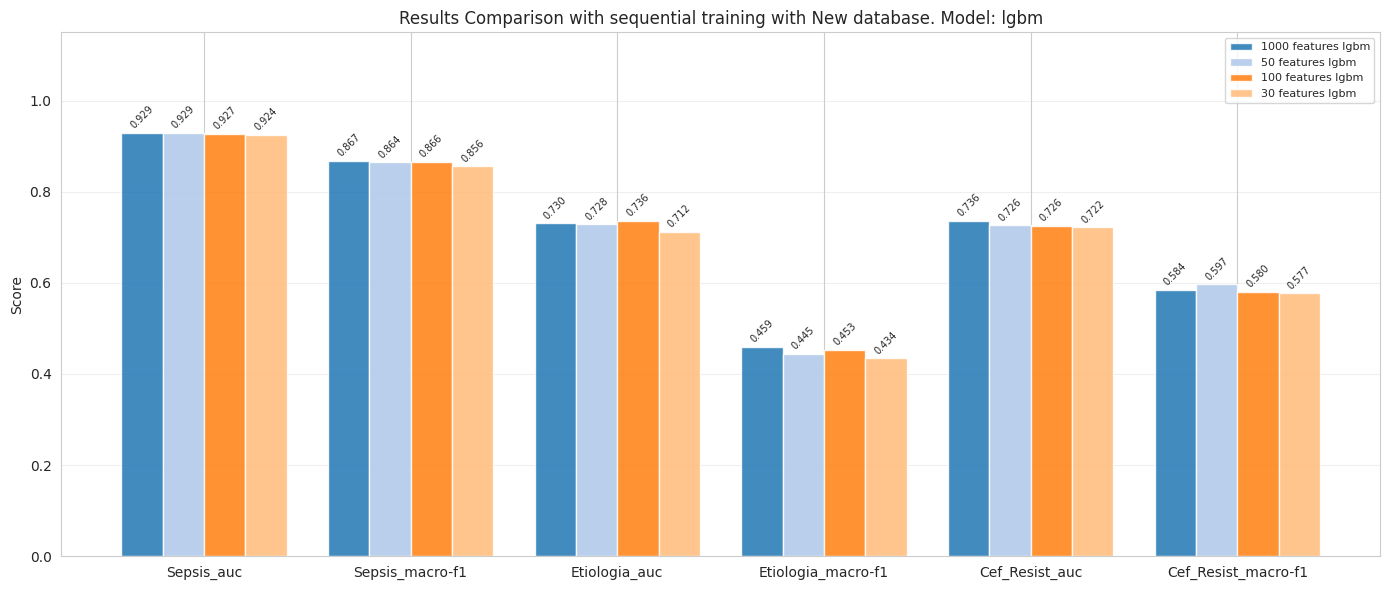

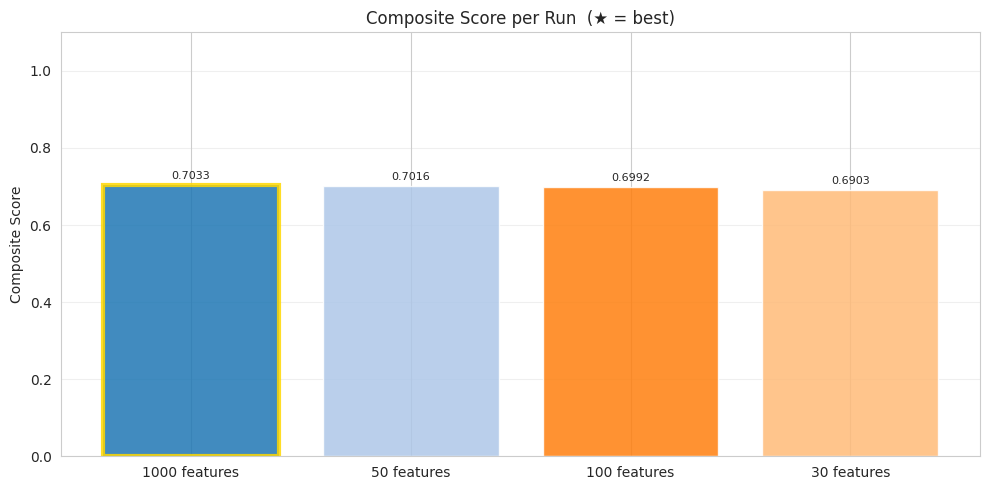

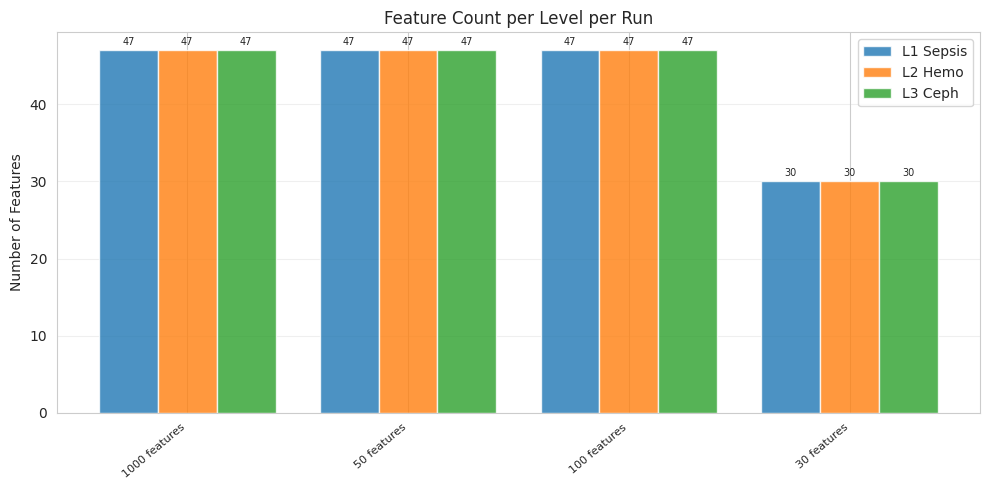


results_dir set to best run:
  /data/ucct/bi/scratch_tmp/bi/TESTS/pmata_mepram_tests/cascade_modelling/outputs/hierarchical_independent_featureesp_lgbm_1000f_20260320121018_5457755


In [94]:
import re
from datetime import datetime
# ── Configuration ────────────────────────────────────────────────────────────
ROOT_FOLDER = Path('/data/ucct/bi/scratch_tmp/bi/TESTS/pmata_mepram_tests/cascade_modelling/outputs')
# Only consider runs whose embedded timestamp is <= this date (inclusive). Format: "YYYYMMDD"  –  set to None to include all runs.
limit_date = "20260301"   # e.g. "20260319"
TAG = "hierarchical_independent_featureesp"
TITLE = "Results Comparison with sequential training"
# Composite score used to rank runs. Weights applied to [L1_AUC, L1_F1, L2_AUC, L2_F1, L3_AUC, L3_F1].
# Missing metrics (e.g. L3_AUC when None) are skipped and the remaining weights are re-normalised automatically.
SCORE_WEIGHTS = dict(Sepsis_f1=1, Sepsis_auc=1, Etiologia_auc=1, Etiologia_f1=1, Cef_Resist_f1=2, Cef_Resist_auc=2)

# ── Helpers ───────────────────────────────────────────────────────────────────
_TS_RE = re.compile(r"(\d{14})")   # matches YYYYMMDDHHMMSS inside folder name

def _parse_run_ts(folder_name: str):
    """Return datetime parsed from the 14-digit timestamp in the folder name, or None."""
    m = _TS_RE.search(folder_name)
    if m:
        try:
            return datetime.strptime(m.group(1), "%Y%m%d%H%M%S")
        except ValueError:
            pass
    return None, None

def _load_level_features(run_dir: Path, level_subdir: str) -> list | None:
    """Load the features list from a level's summary.json, or return None if unavailable."""
    summary_path = run_dir / level_subdir / "summary.json"
    if not summary_path.exists():
        return None
    try:
        with open(summary_path) as f:
            s = json.load(f)
        return s.get("features")
    except Exception:
        return None

def _load_run(run_dir: Path) -> dict | None:
    """Load aggregate_summary.json + per-level features for one run; return a flat metrics dict or None."""
    summary_path = run_dir / "aggregate_summary.json"
    if not summary_path.exists():
        return None, None
    try:
        with open(summary_path) as f:
            agg = json.load(f)
    except Exception:
        return None, None

    row = {"run": run_dir.name, "path": str(run_dir)}
    ts = _parse_run_ts(run_dir.name)
    row["run_datetime"] = ts.strftime("%Y-%m-%d %H:%M:%S") if ts else "unknown"
    l3_tag = "level3_cefalosporina" if "level3_cefalosporina" in agg else "level3_cef"
    l1 = agg.get("level1_sepsis", {})
    l2 = agg.get("level2_hemo", {})
    l3 = agg.get(l3_tag, {})
    model_type = agg.get("args", {}).get("model_type")
    max_f = agg.get("args", {}).get("max_features")
    """if agg.get("args", {}).get("binary_trials") != "1000":
        return None, None"""
    db_name = None
    if agg.get("args", {}).get("database_file") == "/mnt/mepram_data/df_merged_full_multilabel_grouped.csv":
        db_name = "New database"
    elif agg.get("args", {}).get("database_file") == "/mnt/mepram_data/df_merged_full_multilabel_grouped_old.csv":
        db_name = "Old database"
    row["Sepsis_f1"]  = l1.get("macro_f1")
    row["Sepsis_auc"] = l1.get("roc_auc")
    row["Etiologia_f1"]  = l2.get("macro_f1")
    row["Etiologia_auc"] = l2.get("roc_auc")
    row["Cef_Resist_f1"]  = l3.get("macro_f1")
    row["Cef_Resist_auc"] = l3.get("roc_auc")   # None for some multiclass experiments
    row["model_type"] = model_type
    row["max_features"] = max_f

    # ── Features (from per-level summary.json) ────────────────────────────────
    for lvl, subdir in [("l1", "level1_sepsis"), ("l2", "level2_hemo"), ("l3", l3_tag)]:
        feats = _load_level_features(run_dir, subdir)
        row[f"{lvl}_features"] = feats
        row[f"{lvl}_n_features"] = len(feats) if feats is not None else None

    return row, db_name

# ── Scan & filter ─────────────────────────────────────────────────────────────
limit_dt = None
if limit_date:
    limit_dt = datetime.strptime(limit_date, "%Y%m%d")
DB_NAME = None
runs = []
for d in sorted(ROOT_FOLDER.glob("*")):
    if not d.is_dir():
        continue
    if not TAG in d.name:
        continue
    ts = _parse_run_ts(d.name)
    if limit_dt is not None and ts is not None and ts < limit_dt:
        continue
    row, db_name = _load_run(d)
    if db_name:
        if not DB_NAME:
            DB_NAME = db_name
        elif db_name != DB_NAME:
            DB_NAME = DB_NAME + " & " + db_name
    if row is not None:
        runs.append(row)

if not runs:
    print("No valid cascade runs found in:", ROOT_FOLDER)
else:
    runs_df = pd.DataFrame(runs)

    # ── Composite score ───────────────────────────────────────────────────────
    _score_cols = {"model_type", "l1_features", "l2_features", "l3_features", "max_features"}
    def _composite(row):
        total_w, total_s = 0.0, 0.0
        for col, w in SCORE_WEIGHTS.items():
            v = row.get(col)
            if v is not None and not (isinstance(v, float) and np.isnan(v)):
                total_s += float(v) * w
                total_w += w
        return total_s / total_w if total_w > 0 else np.nan

    runs_df["composite_score"] = runs_df.drop(columns=list(_score_cols & set(runs_df.columns))).apply(_composite, axis=1)
    runs_df = runs_df.sort_values("composite_score", ascending=False).reset_index(drop=True)

    # ── Display table ─────────────────────────────────────────────────────────
    display_cols = ["run", "run_datetime", "max_features",
                    "Sepsis_auc", "Sepsis_f1", "l1_n_features",
                    "Etiologia_auc", "Etiologia_f1", "l2_n_features",
                    "Cef_Resist_auc", "Cef_Resist_f1", "l3_n_features",
                    "composite_score"]
    display_cols = [c for c in display_cols if c in runs_df.columns]

    print(f"Found {len(runs_df)} valid runs" +
          (f" up to {limit_date}" if limit_date else "") + "\n")
    print("=" * 140)
    print("RUNS RANKED BY COMPOSITE SCORE")
    print("=" * 140)
    print(runs_df[display_cols].to_string(index=True, float_format=lambda x: f"{x:.4f}"))
    print("=" * 140)

    best_row = runs_df.iloc[0]
    print(f"\n★  Best run:  {best_row['run']}")
    print(f"   Model: {best_row['model_type']}"
          f"  |  Composite: {best_row['composite_score']:.4f}"
          f"  |  L1 AUC {best_row['Sepsis_auc']:.4f}  F1 {best_row['Sepsis_f1']:.4f}  ({best_row['l1_n_features']} feats)"
          f"  |  L2 AUC {best_row['Etiologia_auc']:.4f}  F1 {best_row['Etiologia_f1']:.4f}  ({best_row['l2_n_features']} feats)"
          f"  |  L3 AUC {best_row['Cef_Resist_auc'] if best_row['Cef_Resist_auc'] is not None else 'N/A'}"
          f"  F1 {best_row['Cef_Resist_f1']:.4f}  ({best_row['l3_n_features']} feats)")

    # ── Bar chart comparison ──────────────────────────────────────────────────
    metric_pairs = [("Sepsis_auc", "Sepsis_auc"), ("Sepsis_f1", "Sepsis_macro-f1"),
                    ("Etiologia_auc", "Etiologia_auc"), ("Etiologia_f1", "Etiologia_macro-f1"),
                    ("Cef_Resist_auc", "Cef_Resist_auc"), ("Cef_Resist_f1", "Cef_Resist_macro-f1")]

    n_runs = len(runs_df)
    n_metrics = len(metric_pairs)
    x = np.arange(n_metrics)
    bar_w = min(0.8 / max(n_runs, 1), 0.25)
    colors = plt.cm.tab20.colors

    fig, ax = plt.subplots(figsize=(max(14, n_metrics * 1.5 + n_runs * 0.8), 6))
    for i, (_, row) in enumerate(runs_df.iterrows()):
        vals = [row[col] if row[col] is not None else np.nan for col, _ in metric_pairs]
        offset = (i - (n_runs - 1) / 2) * bar_w
        bars = ax.bar(x + offset, vals, bar_w, alpha=0.85,
                      color=colors[i % len(colors)],
                      label=row["max_features"] + " features " + row["model_type"])
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                        f"{v:.3f}", ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels([label for _, label in metric_pairs])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"{TITLE} with {DB_NAME}. Model: {runs_df["model_type"].loc[0]}")
    ax.legend(loc='upper right', fontsize=8, ncol=max(1, n_runs // 5))
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # ── Composite score bar ───────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(max(10, n_runs * 0.9 + 2), 5))
    bar_colors = [colors[i % len(colors)] for i in range(n_runs)]
    bars2 = ax2.bar(range(n_runs), runs_df["composite_score"], color=bar_colors, alpha=0.85)
    bars2[0].set_edgecolor("gold"); bars2[0].set_linewidth(3)  # highlight best
    ax2.set_xticks(range(n_runs))
    ax2.set_xticklabels(
        [r + " features" for r in runs_df["max_features"]]
    )
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel("Composite Score")
    ax2.set_title("Composite Score per Run  (★ = best)")
    ax2.grid(True, alpha=0.3, axis='y')
    for b, v in zip(bars2, runs_df["composite_score"]):
        ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{v:.4f}", ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Feature count comparison ──────────────────────────────────────────────
    feat_cols = ["l1_n_features", "l2_n_features", "l3_n_features"]
    feat_labels = ["L1 Sepsis", "L2 Hemo", "L3 Ceph"]
    feat_data = runs_df[feat_cols].values.astype(float)

    fig3, ax3 = plt.subplots(figsize=(max(10, n_runs * 0.9 + 2), 5))
    feat_bar_w = min(0.8 / max(len(feat_cols), 1), 0.3)
    x3 = np.arange(n_runs)
    feat_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for j, (col, label, fc) in enumerate(zip(feat_cols, feat_labels, feat_colors)):
        offset = (j - 1) * feat_bar_w
        vals = runs_df[col].values.astype(float)
        bars3 = ax3.bar(x3 + offset, vals, feat_bar_w, alpha=0.8, color=fc, label=label)
        for b, v in zip(bars3, vals):
            if not np.isnan(v):
                ax3.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                         f"{int(v)}", ha='center', va='bottom', fontsize=7)
    ax3.set_xticks(x3)
    ax3.set_xticklabels(
        [r + " features" for r in runs_df["max_features"]],
        rotation=40, ha='right', fontsize=8
    )
    ax3.set_ylabel("Number of Features")
    ax3.set_title("Feature Count per Level per Run")
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # ── Optionally point results_dir at the best run ──────────────────────────
    best_path = Path(best_row["path"])
    if best_path.exists():
        results_dir = best_path
        print(f"\nresults_dir set to best run:\n  {results_dir}")
    else:
        print(f"\nWarning: best run path does not exist locally:\n  {best_path}")


## Extended Metrics Across All Runs

Iterates every run under `root_folder`, recomputes metrics not stored in the summaries from the saved `predictions.csv` files, and displays a per-level table.

Computed metrics (macro/micro pairs for F1, F2, AUC):
- **macro_f1** (stored) vs **micro_f1** (recomputed)
- **macro_f2** / **micro_f2** — F-beta with β=2 (recall-weighted)
- **macro_auc** / **micro_auc** — OvR ROC-AUC; for binary levels macro == micro; the split is meaningful only for the multiclass L2 Hemo level.


  L1 Sepsis  --  8 run(s)  (macro_auc == micro_auc for binary)
                                                                  run     run_datetime  n_samples  n_features  macro_f1  micro_f1  macro_f2  micro_f2  macro_auc  micro_auc
indep_cascade_three_level_shaprfecv_catb_1000f_20260325150523_5468880 2026-03-25 15:05        679          48    0.8704    0.8704    0.8703    0.8704     0.9332     0.9332
 indep_cascade_three_level_shaprfecv_catb_100f_20260325150530_5468881 2026-03-25 15:05        679          48    0.8689    0.8689    0.8689    0.8689     0.9344     0.9344
 indep_cascade_three_level_shaprfecv_catb_100f_20260325150557_5468886 2026-03-25 15:05        679          48    0.8671    0.8675    0.8668    0.8675     0.9338     0.9338
  indep_cascade_three_level_shaprfecv_catb_25f_20260325150538_5468883 2026-03-25 15:05        679          25    0.8614    0.8616    0.8613    0.8616     0.9306     0.9306
  indep_cascade_three_level_shaprfecv_catb_25f_20260325150546_5468884 2026-0

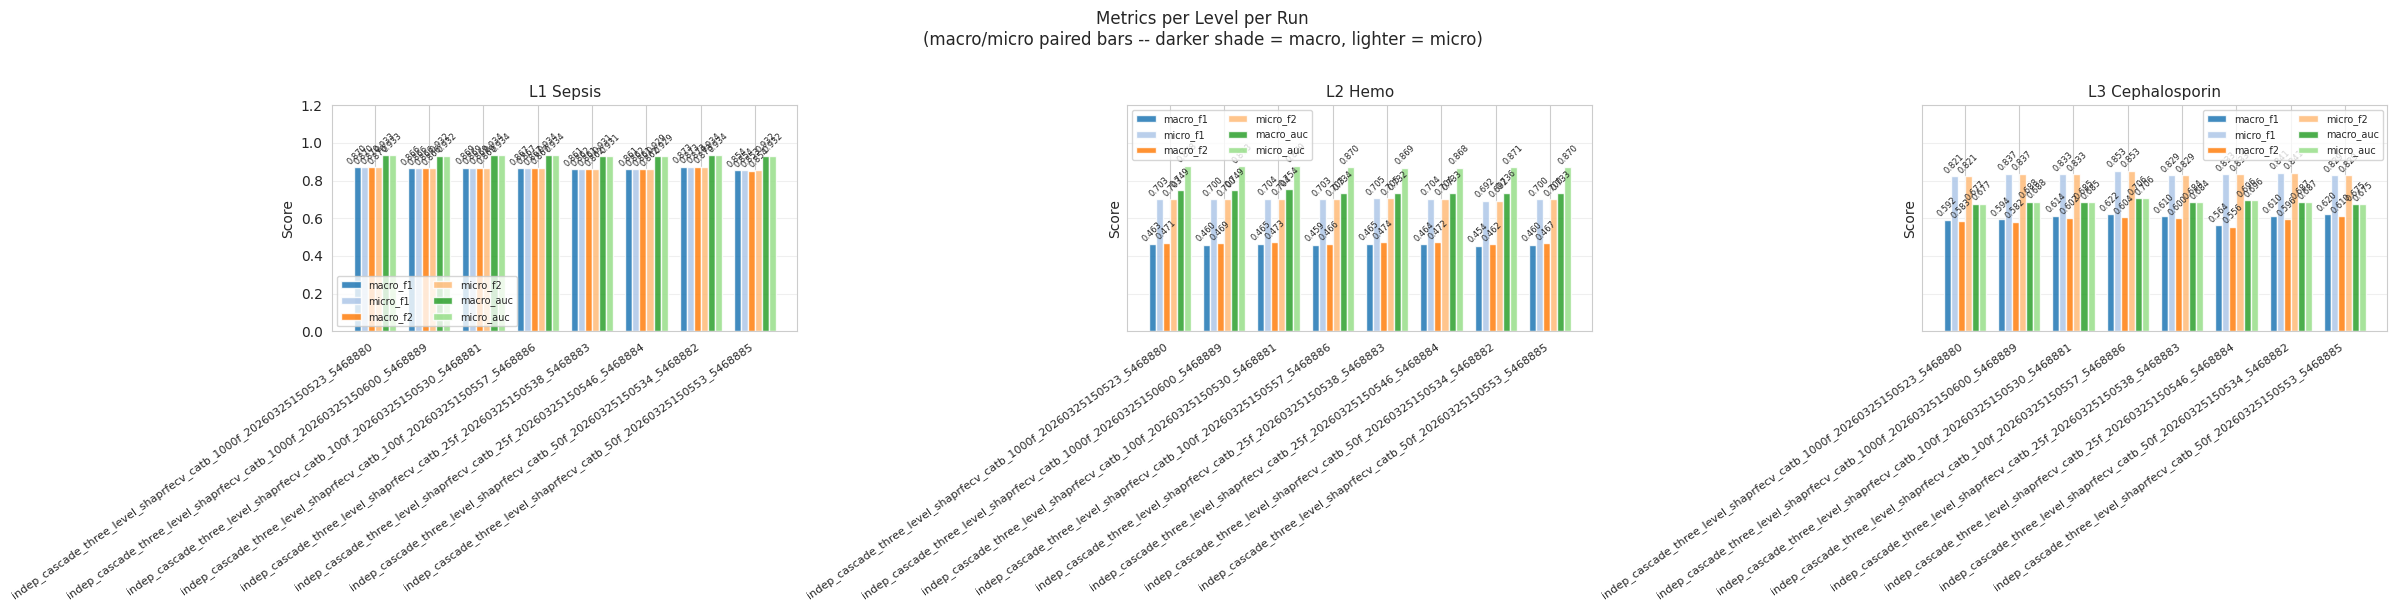


Total evaluated: 8 run(s), 24 level-entries.


In [116]:
from sklearn.metrics import (
    f1_score, fbeta_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ── Configuration ─────────────────────────────────────────────────────────────
# root_folder is defined in cell 3; override here if needed.
# root_folder = Path('/data/ucct/bi/scratch_tmp/bi/TESTS/...')

# ── Helpers ────────────────────────────────────────────────────────────────────
TAG = "indep_cascade_three_level_shaprfecv_catb"
limit_date = "20260323"
USE_TAG_FILTER = True
USE_LIMIT_DATE = True
def _compute_auc(y_true, preds_df, classes, average):
    """
    Compute ROC-AUC with the requested averaging strategy.
    - Binary     : roc_auc_score on the single proba column (average is irrelevant;
                   macro == micro == the scalar AUC for 2 classes).
    - Multiclass : OvR using per-class proba_* columns; `average` distinguishes
                   macro vs micro (macro weights classes equally, micro weights by support).
    """
    proba_cols = [c for c in preds_df.columns if c.startswith("proba_")]

    if len(classes) == 2:
        if "proba" in preds_df.columns:
            y_score = preds_df["proba"].values
        elif len(proba_cols) >= 2:
            y_score = preds_df[proba_cols[1]].values
        else:
            return float("nan")
        try:
            return roc_auc_score(y_true, y_score)
        except Exception:
            return float("nan")
    else:
        if not proba_cols:
            return float("nan")
        y_score = preds_df[proba_cols].values
        y_bin   = label_binarize(y_true, classes=list(range(len(classes))))
        try:
            return roc_auc_score(y_bin, y_score, average=average, multi_class="ovr")
        except Exception:
            return float("nan")


def _extended_metrics_for_run(run_dir: Path):
    """
    Return a list of dicts (one per level) with extended metrics for a single run.
    Uses params from summary.json to confirm the entry is valid.
    """
    rows = []
    subdirs = [x.name for x in run_dir.glob("*")]
    level3_subdir = "level3_cefalosporina" if "level3_cefalosporina" in subdirs else "level3_cef"
    LEVEL_SUBDIRS = [
        ("L1 Sepsis",        "level1_sepsis"),
        ("L2 Hemo",          "level2_hemo"),
        ("L3 Cephalosporin", level3_subdir),
    ]

    for level_label, subdir in LEVEL_SUBDIRS:
        level_dir    = run_dir / subdir
        summary_path = level_dir / "summary.json"
        preds_path   = level_dir / "predictions.csv"

        if not summary_path.exists() or not preds_path.exists():
            continue

        try:
            with open(summary_path) as f:
                summary = json.load(f)
        except Exception:
            continue

        # Require params key — confirms this is a genuine trained-model summary
        params = summary.get("params")
        if params is None:
            continue

        try:
            preds = pd.read_csv(preds_path)
        except Exception:
            continue

        if "true" not in preds.columns or "pred" not in preds.columns:
            continue

        y_true = preds["true"].values
        y_pred = preds["pred"].values

        # Determine class list
        classes = summary.get("classes") or summary.get("hemo_classes") or sorted(set(y_true))

        micro_f1  = f1_score(y_true, y_pred, average="micro",  zero_division=0)
        macro_f2  = fbeta_score(y_true, y_pred, beta=2, average="macro",  zero_division=0)
        micro_f2  = fbeta_score(y_true, y_pred, beta=2, average="micro",  zero_division=0)
        macro_auc = _compute_auc(y_true, preds, classes, average="macro")
        micro_auc = _compute_auc(y_true, preds, classes, average="micro")
        # Note: for binary levels (L1, L3) macro_auc == micro_auc == stored roc_auc.
        # The split is only meaningful for multiclass (L2 Hemo).

        rows.append({
            "run":          run_dir.name,
            "run_datetime": (lambda ts: ts.strftime("%Y-%m-%d %H:%M") if ts else "unknown")(_parse_run_ts(run_dir.name)),
            "level":        level_label,
            "features":     summary.get("features", []),
            "n_samples":    len(preds),
            "n_features":   len(summary.get("features") or []),
            "macro_f1":     summary.get("macro_f1"),
            "micro_f1":     micro_f1,
            "macro_f2":     macro_f2,
            "micro_f2":     micro_f2,
            "macro_auc":    macro_auc,
            "micro_auc":    micro_auc,
            "params":       params,
        })
    return rows

def _get_top_n_features(df: pd.DataFrame, level_label: str, n: int = 10) -> list[dict]:
    """
    Returns the N most common features for a given level across all runs.
    Args:
        df:          DataFrame with 'level' and 'features' columns (features is a list per row)
        level_label: Level to filter by
        n:           Number of top features to return
    Returns:
        List of dicts with level, rank, feature, run_count, n_runs, pct_runs
    """
    from collections import Counter
    subset = df[df["level"] == level_label]
    n_runs = len(subset)
    counter = Counter(
        feat
        for feat_list in subset["features"]
        if feat_list
        for feat in feat_list
    )
    return [
        {
            "level":     level_label,
            "rank":      rank,
            "feature":   feat,
            "run_count": count,
            "n_runs":    n_runs,
            "pct_runs":  round(count / n_runs * 100, 1),
        }
        for rank, (feat, count) in enumerate(counter.most_common(n), start=1)
    ]

# ── Scan all runs ──────────────────────────────────────────────────────────────
all_rows = []
limit_dt = None
if USE_LIMIT_DATE:
    if limit_date:
        limit_dt = datetime.strptime(limit_date, "%Y%m%d")
for d in sorted(ROOT_FOLDER.glob("*")):
    if not d.is_dir():
        continue
    if USE_TAG_FILTER:
        if not TAG in d.name:
            continue
    ts = _parse_run_ts(d.name)
    if limit_dt is not None and ts is not None and ts < limit_dt:
        continue
    all_rows.extend(_extended_metrics_for_run(d))

if not all_rows:
    print("No valid runs found under:", ROOT_FOLDER)
else:
    ext_df = pd.DataFrame(all_rows)

    # ── Per-level display ──────────────────────────────────────────────────────
    metric_cols  = ["macro_f1", "micro_f1", "macro_f2", "micro_f2", "macro_auc", "micro_auc"]
    display_cols = ["run", "run_datetime", "n_samples", "n_features"] + metric_cols
    top_features_rows = []
    for level_label in ext_df["level"].unique():
        subset = ext_df[ext_df["level"] == level_label].copy()
        subset = subset.sort_values("run_datetime", ascending=True).reset_index(drop=True)
        is_binary = level_label != "L2 Hemo"
        note = "  (macro_auc == micro_auc for binary)" if is_binary else "  (macro_auc != micro_auc for multiclass)"
        print(f"\n{'='*130}")
        print(f"  {level_label}  --  {len(subset)} run(s){note}")
        print(f"{'='*130}")
        print(subset[[c for c in display_cols if c in subset.columns]]
              .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
        top_features_rows.extend(_get_top_n_features(ext_df, level_label, 50))
        
    # Dataframe with the consensus top features across all runs
    top_features_df = pd.DataFrame(top_features_rows)
    print(top_features_df)
    # ── Grouped bar chart: all metrics per run per level ──────────────────────
    all_metrics = ["macro_f1", "micro_f1", "macro_f2", "micro_f2", "macro_auc", "micro_auc"]
    levels      = ext_df["level"].unique()

    fig, axes = plt.subplots(1, len(levels), figsize=(8 * len(levels), 6), sharey=True)
    if len(levels) == 1:
        axes = [axes]

    bar_colors = {
        "macro_f1":  "#1f77b4", "micro_f1":  "#aec7e8",
        "macro_f2":  "#ff7f0e", "micro_f2":  "#ffbb78",
        "macro_auc": "#2ca02c", "micro_auc": "#98df8a",
    }
    bar_w = 0.13

    for ax, level_label in zip(axes, levels):
        subset   = ext_df[ext_df["level"] == level_label].copy()
        n_runs   = len(subset)
        x        = np.arange(n_runs)
        x_labels = [r for r in subset["run"].values]

        for j, metric in enumerate(all_metrics):
            offset = (j - (len(all_metrics) - 1) / 2) * bar_w
            vals   = subset[metric].values
            bars   = ax.bar(x + offset, vals, bar_w, alpha=0.85,
                            color=bar_colors[metric], label=metric)
            for b, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                            f"{v:.3f}", ha="center", va="bottom", fontsize=6, rotation=45)

        ax.set_title(level_label, fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=35, ha="right", fontsize=8)
        ax.set_ylim(0, 1.2)
        ax.set_ylabel("Score")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3, axis="y")

    fig.suptitle("Metrics per Level per Run\n(macro/micro paired bars -- darker shade = macro, lighter = micro)",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"\nTotal evaluated: {len(ext_df['run'].unique())} run(s), "
          f"{len(ext_df)} level-entries.")


In [117]:
import os
os.makedirs(f"{LOCAL_OUTPUT_DIR}/top_features_tables", exist_ok=True)
if USE_TAG_FILTER:
    top_features_df.to_csv(f"{LOCAL_OUTPUT_DIR}/top_features_tables/top_features_df_{"_".join(TAG.split("_")[-2:])}.csv", index=False)
else:
    top_features_df.to_csv(f"{LOCAL_OUTPUT_DIR}/top_features_tables/top_features_df_global.csv", index=False)

----------------

# Individual analysis   -------------------------------------------------------------------------------------------

## 1. Load Results

Specify the output directory from your training run:

In [ ]:
# UPDATE THIS PATH to your specific training run
results_dir = Path(
    '/data/ucct/bi/scratch_tmp/bi/TESTS/pmata_mepram_tests/cascade_modelling/outputs'
)
results_dir = results_dir / 'cascade_three_level_cefmult_optim_lgbm_20260318131142_5445835' #
# "cascade_three_level_shaprfecv_20260226092447_5352055" "cascade_three_level_shaprfecv_20260225160322_5343290"
# Alternatively, auto-detect the most recent run:
outputs_base = Path('/data/ucct/bi/scratch_tmp/bi/TESTS/pmata_mepram_tests/cascade_modelling/outputs')
cascade_runs = sorted(outputs_base.glob('cascade_three_level_*'))
if cascade_runs and not results_dir.exists():
    results_dir = cascade_runs[-1]  # Most recent
    print(f"Auto-detected most recent run: {results_dir.name}")
else:
    print(f"Using specified directory: {results_dir}")

# Check if directory exists
if not results_dir.exists():
    raise FileNotFoundError(f"Results directory not found: {results_dir}")

print(f"\nLoading results from: {results_dir}")

In [ ]:
# Load aggregate summary
with open(results_dir / "aggregate_summary.json") as f:
    aggregate = json.load(f)

print("Aggregate Summary:")
print(json.dumps({k:v for k,v in aggregate.items() if "rfecv" not in k}, indent=2))

In [ ]:
# Load Level 1 (Sepsis)
l1_dir = results_dir / "level1_sepsis"
with open(l1_dir / "summary.json") as f:
    l1_summary = json.load(f)
l1_preds = pd.read_csv(l1_dir / "predictions.csv")
l1_trials = pd.read_csv(l1_dir / "optuna_trials.csv")

print(f"\nLevel 1 - Sepsis")
print(f"  Macro F1: {l1_summary['macro_f1']:.4f}")
print(f"  ROC AUC: {l1_summary['roc_auc']:.4f}")
print(f"  Threshold: {l1_summary['threshold']:.4f}")
print(f"  Test samples: {len(l1_preds)}")
print(f"  Features used: {len(l1_summary['features'])}")

In [ ]:
# Load Level 2 (Hemo)
l2_dir = results_dir / "level2_hemo"
with open(l2_dir / "summary.json") as f:
    l2_summary = json.load(f)
l2_preds = pd.read_csv(l2_dir / "predictions.csv")
l2_trials = pd.read_csv(l2_dir / "optuna_trials.csv")

print(f"\nLevel 2 - Hemo")
print(f"  Macro F1: {l2_summary['macro_f1']:.4f}")
print(f"  ROC AUC: {l2_summary['roc_auc']:.4f}")
print(f"  Classes: {l2_summary['hemo_classes']}")
print(f"  Test samples: {len(l2_preds)}")
print(f"  Features used: {len(l2_summary['features'])}")

In [ ]:
# Load Level 3 (Cephalosporin resistance)
l3_dir = results_dir / "level3_cefalosporina"
with open(l3_dir / "summary.json") as f:
    l3_summary = json.load(f)
l3_preds = pd.read_csv(l3_dir / "predictions.csv")
l3_trials = pd.read_csv(l3_dir / "optuna_trials.csv")

# Auto-detect whether L3 is binary or multiclass
l3_classes = l3_summary.get('classes', [0, 1])
l3_is_binary = len(l3_classes) == 2
l3_type_label = "Binary" if l3_is_binary else "Multiclass"
l3_num_classes = len(l3_classes)

# For binary: a single 'proba' column (positive class probability) may exist,
# or we derive it from the proba_* columns if present.
l3_proba_cols = [c for c in l3_preds.columns if c.startswith("proba_")]
if l3_is_binary and "proba" not in l3_preds.columns and l3_proba_cols:
    # Use the probability of the positive class (index 1)
    l3_preds["proba"] = l3_preds[l3_proba_cols[1]]

print(f"\nLevel 3 - Cephalosporin Resistance  [{l3_type_label}]")
print(f"  Classes ({l3_num_classes}): {l3_classes}")
print(f"  Macro F1:    {l3_summary['macro_f1']:.4f}")
if l3_summary.get('roc_auc') is not None:
    print(f"  ROC AUC:     {l3_summary['roc_auc']:.4f}")
if l3_is_binary and l3_summary.get('threshold') is not None:
    print(f"  Threshold:   {l3_summary['threshold']:.4f}")
print(f"  Test samples: {len(l3_preds)}")
print(f"  Features used: {len(l3_summary['features'])}")

In [ ]:
l3_summary['features']

## 2. Confusion Matrices

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title, normalize=False):
    """Plot confusion matrix with optional normalization."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        cmap = 'Blues'
    else:
        fmt = 'd'
        cmap = 'Blues'
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap, 
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Proportion' if normalize else 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return cm

In [ ]:
# Level 1: Sepsis confusion matrix
print("Level 1: Sepsis Prediction")
cm_l1 = plot_confusion_matrix(
    l1_preds['true'], 
    l1_preds['pred'],
    labels=[0, 1],
    title='Level 1: Sepsis Confusion Matrix (Counts)'
)

cm_l1_norm = plot_confusion_matrix(
    l1_preds['true'], 
    l1_preds['pred'],
    labels=[0, 1],
    title='Level 1: Sepsis Confusion Matrix (Normalized)',
    normalize=True
)

In [ ]:
# Level 2: Hemo confusion matrix
print("Level 2: Hemocultive Result")
hemo_labels = list(range(len(l2_summary['hemo_classes'])))
hemo_classes = l2_summary['hemo_classes']

cm_l2 = plot_confusion_matrix(
    l2_preds['true'], 
    l2_preds['pred'],
    labels=hemo_labels,
    title='Level 2: Hemocultive Confusion Matrix (Counts)'
)

# Update tick labels with class names
plt.figure(figsize=(10, 8))
sns.heatmap(cm_l2, annot=True, fmt='d', cmap='Blues',
            xticklabels=hemo_classes, yticklabels=hemo_classes)
plt.title('Level 2: Hemocultive Confusion Matrix (Counts)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized version
cm_l2_norm = cm_l2.astype('float') / cm_l2.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_l2_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=hemo_classes, yticklabels=hemo_classes,
            cbar_kws={'label': 'Proportion'})
plt.title('Level 2: Hemocultive Confusion Matrix (Normalized)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Level 3: Cephalosporin resistance confusion matrix
print(f"Level 3: Cephalosporin Resistance  [{l3_type_label}]")
l3_labels = list(range(l3_num_classes))

cm_l3 = plot_confusion_matrix(
    l3_preds['true'],
    l3_preds['pred'],
    labels=l3_labels,
    title=f'Level 3: Cephalosporin Resistance Confusion Matrix (Counts) [{l3_type_label}]'
)

if l3_is_binary:
    # Simple normalized 2x2
    cm_l3_norm = plot_confusion_matrix(
        l3_preds['true'],
        l3_preds['pred'],
        labels=l3_labels,
        title='Level 3: Cephalosporin Resistance Confusion Matrix (Normalized)',
        normalize=True
    )
else:
    # Multi-panel confusion matrix with class names on axes
    cm_l3_norm = cm_l3.astype('float') / cm_l3.sum(axis=1)[:, np.newaxis]
    fig, axes = plt.subplots(1, 2, figsize=(max(10, l3_num_classes * 1.5 + 2),
                                            max(8, l3_num_classes * 1.2 + 2)))
    for ax, data, fmt, ttl in zip(
        axes,
        [cm_l3, cm_l3_norm],
        ['d', '.2f'],
        ['Counts', 'Normalized'],
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=l3_classes, yticklabels=l3_classes)
        ax.set_title(f'Level 3: Cephalosporin ({ttl})')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

## 3. ROC Curves (Binary Levels)

In [ ]:
def plot_roc_curve(y_true, y_proba, title, threshold=None):
    """Plot ROC curve with AUC."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    
    # Mark the chosen threshold if provided
    if threshold is not None:
        idx = np.argmin(np.abs(thresholds - threshold))
        plt.plot(fpr[idx], tpr[idx], 'ro', markersize=10, 
                label=f'Threshold = {threshold:.4f}')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Level 1: Sepsis ROC
plot_roc_curve(
    l1_preds['true'], 
    l1_preds['proba'],
    'Level 1: Sepsis ROC Curve',
    threshold=l1_summary['threshold']
)

In [ ]:
# Level 3: Cephalosporin resistance ROC curve(s)
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

if l3_is_binary:
    plot_roc_curve(
        l3_preds['true'],
        l3_preds['proba'],
        'Level 3: Cephalosporin Resistance ROC Curve',
        threshold=l3_summary.get('threshold')
    )
else:
    # One-vs-Rest ROC for each class + macro average
    y_true_bin = label_binarize(l3_preds['true'], classes=l3_labels)
    proba_matrix = l3_preds[l3_proba_cols].values  # shape [n, n_classes]

    plt.figure(figsize=(9, 7))
    colors = plt.cm.tab10.colors
    aucs = []
    for i, cls_name in enumerate(l3_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], proba_matrix[:, i])
        roc_auc_i = auc(fpr, tpr)
        aucs.append(roc_auc_i)
        plt.plot(fpr, tpr, lw=2, color=colors[i % 10],
                 label=f'{cls_name} (AUC = {roc_auc_i:.3f})')

    macro_auc = np.mean(aucs)
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Level 3: Cephalosporin OvR ROC Curves  (Macro AUC = {macro_auc:.3f})')
    plt.legend(loc='lower right', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Precision-Recall Curves (Binary Levels)

In [ ]:
def plot_pr_curve(y_true, y_proba, title, threshold=None):
    """Plot Precision-Recall curve."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2,
             label=f'PR curve (AUC = {pr_auc:.4f})')
    
    # Baseline: proportion of positive class
    baseline = np.mean(y_true)
    plt.plot([0, 1], [baseline, baseline], color='navy', lw=2, 
             linestyle='--', label=f'Baseline (pos rate = {baseline:.4f})')
    
    # Mark the chosen threshold if provided
    if threshold is not None and len(thresholds) > 0:
        idx = np.argmin(np.abs(thresholds - threshold))
        plt.plot(recall[idx], precision[idx], 'ro', markersize=10,
                label=f'Threshold = {threshold:.4f}')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Level 1: Sepsis PR
plot_pr_curve(
    l1_preds['true'], 
    l1_preds['proba'],
    'Level 1: Sepsis Precision-Recall Curve',
    threshold=l1_summary['threshold']
)

In [ ]:
# Level 3: Cephalosporin resistance Precision-Recall curve(s)
if l3_is_binary:
    plot_pr_curve(
        l3_preds['true'],
        l3_preds['proba'],
        'Level 3: Cephalosporin Resistance Precision-Recall Curve',
        threshold=l3_summary.get('threshold')
    )
else:
    # Per-class PR curves (OvR)
    y_true_bin = label_binarize(l3_preds['true'], classes=l3_labels)
    proba_matrix = l3_preds[l3_proba_cols].values

    plt.figure(figsize=(9, 7))
    colors = plt.cm.tab10.colors
    for i, cls_name in enumerate(l3_classes):
        precision_i, recall_i, _ = precision_recall_curve(y_true_bin[:, i], proba_matrix[:, i])
        pr_auc_i = auc(recall_i, precision_i)
        baseline_i = y_true_bin[:, i].mean()
        plt.plot(recall_i, precision_i, lw=2, color=colors[i % 10],
                 label=f'{cls_name} (AUC = {pr_auc_i:.3f}, base = {baseline_i:.2f})')

    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Level 3: Cephalosporin OvR Precision-Recall Curves')
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Metrics Summary Table

In [ ]:
# Create a summary DataFrame
summary_df = pd.DataFrame([
    {
        'Level': 'L1: Sepsis',
        'Type': 'Binary',
        'Macro F1': l1_summary['macro_f1'],
        'ROC AUC': l1_summary.get('roc_auc'),
        'Threshold': l1_summary.get('threshold'),
        'Test Samples': len(l1_preds),
        'Features': len(l1_summary['features']),
    },
    {
        'Level': 'L2: Hemo',
        'Type': 'Multiclass',
        'Macro F1': l2_summary['macro_f1'],
        'ROC AUC': l2_summary.get('roc_auc'),
        'Threshold': None,
        'Test Samples': len(l2_preds),
        'Features': len(l2_summary['features']),
    },
    {
        'Level': 'L3: Cephalosporin',
        'Type': l3_type_label,
        'Macro F1': l3_summary['macro_f1'],
        'ROC AUC': l3_summary.get('roc_auc'),
        'Threshold': l3_summary.get('threshold') if l3_is_binary else None,
        'Test Samples': len(l3_preds),
        'Features': len(l3_summary['features']),
    },
])

print("\n" + "="*80)
print("METRICS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

In [ ]:
# Visualize metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Macro F1 comparison
axes[0].bar(summary_df['Level'], summary_df['Macro F1'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Macro F1 Score')
axes[0].set_title('Macro F1 Score by Level')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(summary_df['Macro F1']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Test samples comparison
axes[1].bar(summary_df['Level'], summary_df['Test Samples'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Number of Test Samples')
axes[1].set_title('Test Set Size by Level')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(summary_df['Test Samples']):
    axes[1].text(i, v + (v*0.02), f'{v}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Optuna Optimization History

In [ ]:
def plot_optuna_history(trials_df, title):
    """Plot Optuna optimization history."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Optimization history
    axes[0].plot(trials_df['number'], trials_df['value'], alpha=0.6, label='Trial value')
    
    # Running best
    best_so_far = trials_df['value'].cummax()
    axes[0].plot(trials_df['number'], best_so_far, 'r-', linewidth=2, label='Best so far')
    
    axes[0].set_xlabel('Trial Number')
    axes[0].set_ylabel('Objective Value (Macro F1)')
    axes[0].set_title(f'{title} - Optimization History')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Value distribution
    axes[1].hist(trials_df['value'], bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(trials_df['value'].max(), color='r', linestyle='--', 
                   linewidth=2, label=f'Best = {trials_df["value"].max():.4f}')
    axes[1].set_xlabel('Objective Value (Macro F1)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{title} - Value Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Level 1 Optuna history
plot_optuna_history(l1_trials, 'Level 1: Sepsis')

In [ ]:
# Level 2 Optuna history
plot_optuna_history(l2_trials, 'Level 2: Hemo')

In [ ]:
# Level 3 Optuna history
plot_optuna_history(l3_trials, 'Level 3: Cephalosporin')

## 7. Class Distribution in Predictions

In [ ]:
# Level 1: Sepsis class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

l1_true_counts = l1_preds['true'].value_counts().sort_index()
l1_pred_counts = l1_preds['pred'].value_counts().sort_index()

x = np.arange(len(l1_true_counts))
width = 0.35

axes[0].bar(x - width/2, l1_true_counts.values, width, label='True', alpha=0.8)
axes[0].bar(x + width/2, l1_pred_counts.values, width, label='Predicted', alpha=0.8)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Level 1: Sepsis - True vs Predicted Distribution')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['No Sepsis (0)', 'Sepsis (1)'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Probability distribution
axes[1].hist(l1_preds[l1_preds['true']==0]['proba'], bins=30, alpha=0.6, label='No Sepsis (0)', edgecolor='black')
axes[1].hist(l1_preds[l1_preds['true']==1]['proba'], bins=30, alpha=0.6, label='Sepsis (1)', edgecolor='black')
axes[1].axvline(l1_summary['threshold'], color='r', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Level 1: Probability Distribution by True Class')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Level 2: Hemo class distribution
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

l2_true_counts = l2_preds['true'].value_counts().sort_index()
l2_pred_counts = l2_preds['pred'].value_counts().sort_index()

x = np.arange(len(hemo_classes))
width = 0.35

# Ensure all classes are represented
true_vals = [l2_true_counts.get(i, 0) for i in range(len(hemo_classes))]
pred_vals = [l2_pred_counts.get(i, 0) for i in range(len(hemo_classes))]

ax.bar(x - width/2, true_vals, width, label='True', alpha=0.8)
ax.bar(x + width/2, pred_vals, width, label='Predicted', alpha=0.8)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Level 2: Hemocultive - True vs Predicted Distribution')
ax.set_xticks(x)
ax.set_xticklabels(hemo_classes, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Level 3: Cephalosporin resistance class distribution
print(f"Level 3: Cephalosporin Resistance  [{l3_type_label}]")

l3_true_counts = l3_preds['true'].value_counts().sort_index()
l3_pred_counts = l3_preds['pred'].value_counts().sort_index()

if l3_is_binary:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(l3_num_classes)
    width = 0.35
    true_vals = [l3_true_counts.get(i, 0) for i in l3_labels]
    pred_vals = [l3_pred_counts.get(i, 0) for i in l3_labels]

    axes[0].bar(x - width/2, true_vals, width, label='True', alpha=0.8)
    axes[0].bar(x + width/2, pred_vals, width, label='Predicted', alpha=0.8)
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Level 3: Cephalosporin - True vs Predicted Distribution')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([str(c) for c in l3_classes])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    # Probability distribution split by true class
    threshold = l3_summary.get('threshold')
    for cls_idx, cls_name in enumerate(l3_classes):
        axes[1].hist(
            l3_preds[l3_preds['true'] == cls_idx]['proba'],
            bins=30, alpha=0.6, label=str(cls_name), edgecolor='black'
        )
    if threshold is not None:
        axes[1].axvline(threshold, color='r', linestyle='--', linewidth=2,
                        label=f'Threshold = {threshold:.3f}')
    axes[1].set_xlabel('Predicted Probability (positive class)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Level 3: Probability Distribution by True Class')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

else:
    # Multiclass: bar chart of true vs predicted counts + per-class confidence histogram
    fig, axes = plt.subplots(1, 2, figsize=(max(14, l3_num_classes * 1.5 + 4), 5))

    x = np.arange(l3_num_classes)
    width = 0.35
    true_vals = [l3_true_counts.get(i, 0) for i in l3_labels]
    pred_vals = [l3_pred_counts.get(i, 0) for i in l3_labels]

    axes[0].bar(x - width/2, true_vals, width, label='True', alpha=0.8)
    axes[0].bar(x + width/2, pred_vals, width, label='Predicted', alpha=0.8)
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Level 3: Cephalosporin - True vs Predicted Distribution')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([str(c) for c in l3_classes], rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    # Max confidence (chosen class probability) distribution per true class
    colors = plt.cm.tab10.colors
    # 'proba' column in the multiclass predictions is the confidence of the predicted class
    if 'proba' in l3_preds.columns:
        for cls_idx, cls_name in enumerate(l3_classes):
            mask = l3_preds['true'] == cls_idx
            if mask.sum() > 0:
                axes[1].hist(
                    l3_preds.loc[mask, 'proba'],
                    bins=20, alpha=0.55, label=str(cls_name),
                    color=colors[cls_idx % 10], edgecolor='black'
                )
        axes[1].set_xlabel('Predicted Class Confidence')
        axes[1].set_ylabel('Frequency')
        axes[1].set_title('Level 3: Prediction Confidence by True Class')
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3, axis='y')
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

## 8. Feature Count Comparison

In [ ]:
# Feature counts by level
feature_counts = {
    'L1: Sepsis': len(l1_summary['features']),
    'L2: Hemo': len(l2_summary['features']),
    'L3: Cephalosporin': len(l3_summary['features']),
}

plt.figure(figsize=(10, 6))
bars = plt.bar(feature_counts.keys(), feature_counts.values(), 
               color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
plt.ylabel('Number of Features')
plt.title('Feature Count by Level')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNote: L2 and L3 include cascade features from previous levels")
print(f"  L2 features: base features + sepsis_proba (1 cascade feature)")
print(f"  L3 features: base features + sepsis_proba + hemo probabilities ({len(hemo_classes)} cascade features)")

## 9. Export Summary Report

In [ ]:
# Generate a text summary report
report = []
report.append("="*80)
report.append("HIERARCHICAL CASCADE MODEL - EVALUATION REPORT")
report.append("="*80)
report.append(f"Results Directory: {results_dir}")
report.append("\n")

report.append("-" * 80)
report.append("LEVEL 1: SEPSIS PREDICTION (Binary)")
report.append("-" * 80)
report.append(f"Test Samples: {len(l1_preds)}")
report.append(f"Features Used: {len(l1_summary['features'])}")
report.append(f"Macro F1: {l1_summary['macro_f1']:.4f}")
report.append(f"ROC AUC: {l1_summary['roc_auc']:.4f}")
report.append(f"Optimal Threshold: {l1_summary['threshold']:.4f}")
report.append(f"True class distribution: {l1_preds['true'].value_counts().to_dict()}")
report.append("\n")

report.append("-" * 80)
report.append("LEVEL 2: HEMOCULTIVE RESULT (Multiclass)")
report.append("-" * 80)
report.append(f"Test Samples: {len(l2_preds)}")
report.append(f"Features Used: {len(l2_summary['features'])}")
report.append(f"Macro F1: {l2_summary['macro_f1']:.4f}")
report.append(f"Classes: {hemo_classes}")
report.append(f"True class distribution: {l2_preds['true'].value_counts().sort_index().to_dict()}")
report.append("\n")

report.append("-" * 80)
report.append(f"LEVEL 3: CEPHALOSPORIN RESISTANCE ({l3_type_label.upper()})")
report.append("-" * 80)
report.append(f"Test Samples: {len(l3_preds)}")
report.append(f"Features Used: {len(l3_summary['features'])}")
report.append(f"Macro F1: {l3_summary['macro_f1']:.4f}")
if l3_summary.get('roc_auc') is not None:
    report.append(f"ROC AUC: {l3_summary['roc_auc']:.4f}")
if l3_is_binary and l3_summary.get('threshold') is not None:
    report.append(f"Optimal Threshold: {l3_summary['threshold']:.4f}")
report.append(f"Classes: {l3_classes}")
report.append(f"True class distribution: {l3_preds['true'].value_counts().sort_index().to_dict()}")
report.append("\n")

report.append("="*80)
report.append("END OF REPORT")
report.append("="*80)

report_text = "\n".join(report)
print(report_text)

# Save report
report_path = results_dir / "evaluation_report.txt"
with open(report_path, 'w') as f:
    f.write(report_text)

print(f"\nReport saved to: {report_path}")

## 10. Classification Reports

In [ ]:
# Level 1: Sepsis classification report
print("Level 1: Sepsis Classification Report")
print("=" * 60)
print(classification_report(l1_preds['true'], l1_preds['pred'], 
                           target_names=['No Sepsis', 'Sepsis']))
print()

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
legacy_l2_root = Path('/data/ucct/bi/scratch_tmp/bi/TESTS/pmata_mepram_tests/outputs')
legacy_l3_root = Path('/data/ucct/bi/scratch_tmp/bi/TESTS/pmata_mepram_tests/bmr_phenotest/outputs')

# Upper-bound date filter — "YYYYMMDD" or None
legacy_limit_date = None  # e.g. "20260319"

# Composite weights for each task
LEGACY_L2_WEIGHTS = dict(macro_f1=1, multiclass_macro_auc=2)
LEGACY_L3_WEIGHTS = dict(macro_f1=1, binary_roc_auc=2)

# ── Helpers ────────────────────────────────────────────────────────────────────
def _load_legacy_run(run_dir: Path, metric_keys: list[str]) -> dict | None:
    """Parse aggregate_summary.json from a legacy run folder.

    Metrics live under the 'subset_summary' key.  Returns a flat dict with
    the requested metric_keys plus run metadata, or None if the file is absent
    or incomplete.
    """
    summary_path = run_dir / "aggregate_summary.json"
    if not summary_path.exists():
        return None
    try:
        with open(summary_path) as f:
            agg = json.load(f)
    except Exception:
        return None

    ss = agg.get("subset_summary", {})
    if not ss:
        return None

    row = {"run": run_dir.name, "path": str(run_dir)}
    ts = _parse_run_ts(run_dir.name)
    row["run_datetime"] = ts.strftime("%Y-%m-%d %H:%M:%S") if ts else "unknown"
    row["feature_count"] = ss.get("feature_count") or ss.get("binary_feature_count")
    row["classes"] = ss.get("label_encoder_classes") or ss.get("class_names", [])

    for k in metric_keys:
        row[k] = ss.get(k)
    return row


def _rank_legacy(root: Path, glob_pattern: str, metric_keys: list[str],
                 weights: dict, limit_dt) -> pd.DataFrame | None:
    """Scan root for folders matching glob_pattern, load metrics, return ranked DataFrame."""
    rows = []
    for d in sorted(root.glob(glob_pattern)):
        if not d.is_dir():
            continue
        ts = _parse_run_ts(d.name)
        if limit_dt is not None and ts is not None and ts > limit_dt:
            continue
        row = _load_legacy_run(d, metric_keys)
        if row is not None:
            rows.append(row)

    if not rows:
        return None

    df = pd.DataFrame(rows)

    def _score(row):
        total_w, total_s = 0.0, 0.0
        for col, w in weights.items():
            v = row.get(col)
            if v is not None and not (isinstance(v, float) and np.isnan(v)):
                total_s += float(v) * w
                total_w += w
        return total_s / total_w if total_w > 0 else np.nan

    df["composite_score"] = df.apply(_score, axis=1)
    return df.sort_values("composite_score", ascending=False).reset_index(drop=True)


def _print_and_plot_legacy(df: pd.DataFrame, metric_keys: list[str],
                           title: str, limit_date_str: str | None) -> None:
    """Print ranked table + two charts (per-metric bars + composite bar)."""
    display_cols = ["run", "run_datetime", "feature_count"] + metric_keys + ["composite_score"]
    display_cols = [c for c in display_cols if c in df.columns]

    print(f"\nFound {len(df)} valid runs" +
          (f" up to {limit_date_str}" if limit_date_str else "") + "\n")
    print("=" * 110)
    print(f"  {title.upper()}  —  RANKED BY COMPOSITE SCORE")
    print("=" * 110)
    print(df[display_cols].to_string(index=True, float_format=lambda x: f"{x:.4f}"))
    print("=" * 110)

    best = df.iloc[0]
    metric_str = "  ".join(
        f"{k} {best[k]:.4f}" for k in metric_keys if best.get(k) is not None
    )
    print(f"\n★  Best: {best['run']}")
    print(f"   Composite: {best['composite_score']:.4f}  |  {metric_str}")

    colors = plt.cm.tab20.colors
    n_runs = len(df)

    # Per-metric grouped bar chart
    x = np.arange(len(metric_keys))
    bar_w = min(0.8 / max(n_runs, 1), 0.25)
    fig, ax = plt.subplots(figsize=(max(10, len(metric_keys) * 2 + n_runs * 0.8), 5))
    for i, (_, row) in enumerate(df.iterrows()):
        vals = [row.get(k) if row.get(k) is not None else np.nan for k in metric_keys]
        offset = (i - (n_runs - 1) / 2) * bar_w
        bars = ax.bar(x + offset, vals, bar_w, alpha=0.85,
                      color=colors[i % len(colors)],
                      label=row["run"][:50] + ("…" if len(row["run"]) > 50 else ""))
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                        f"{v:.3f}", ha='center', va='bottom', fontsize=7, rotation=45)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_keys)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"{title} — Per-metric Comparison" +
                 (f"  (up to {limit_date_str})" if limit_date_str else ""))
    ax.legend(loc='upper right', fontsize=8, ncol=max(1, n_runs // 5))
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Composite score bar
    fig2, ax2 = plt.subplots(figsize=(max(10, n_runs * 0.9 + 2), 5))
    bar_colors = [colors[i % len(colors)] for i in range(n_runs)]
    bars2 = ax2.bar(range(n_runs), df["composite_score"], color=bar_colors, alpha=0.85)
    bars2[0].set_edgecolor("gold"); bars2[0].set_linewidth(3)
    ax2.set_xticks(range(n_runs))
    ax2.set_xticklabels(
        [r[:35] + "…" if len(r) > 35 else r for r in df["run"]],
        rotation=40, ha='right', fontsize=8
    )
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel("Composite Score")
    ax2.set_title(f"{title} — Composite Score per Run  (★ = best)")
    ax2.grid(True, alpha=0.3, axis='y')
    for b, v in zip(bars2, df["composite_score"]):
        ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{v:.4f}", ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()


# ── Parse limit date ───────────────────────────────────────────────────────────
legacy_limit_dt = None
if legacy_limit_date:
    legacy_limit_dt = datetime.strptime(legacy_limit_date, "%Y%m%d").replace(
        hour=23, minute=59, second=59
    )

# ── L2 legacy scan ─────────────────────────────────────────────────────────────
print("=" * 110)
print("LEGACY L2  —  multiclass hemocultive result")
print("=" * 110)
l2_legacy_df = _rank_legacy(
    legacy_l2_root, "multiclass_optuna_*",
    list(LEGACY_L2_WEIGHTS.keys()), LEGACY_L2_WEIGHTS, legacy_limit_dt,
)
if l2_legacy_df is None:
    print(f"  No valid multiclass_optuna_* runs found in {legacy_l2_root}")
else:
    _print_and_plot_legacy(l2_legacy_df, list(LEGACY_L2_WEIGHTS.keys()),
                           "Legacy L2 Multiclass", legacy_limit_date)

# ── L3 legacy scan ─────────────────────────────────────────────────────────────
print("\n" + "=" * 110)
print("LEGACY L3  —  binary cephalosporin resistance")
print("=" * 110)
l3_legacy_df = _rank_legacy(
    legacy_l3_root, "binary_optuna_*",
    list(LEGACY_L3_WEIGHTS.keys()), LEGACY_L3_WEIGHTS, legacy_limit_dt,
)
if l3_legacy_df is None:
    print(f"  No valid binary_optuna_* runs found in {legacy_l3_root}")
else:
    _print_and_plot_legacy(l3_legacy_df, list(LEGACY_L3_WEIGHTS.keys()),
                           "Legacy L3 Binary", legacy_limit_date)